In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_dihedral_angles)=
# Get dihedral angles

*Getting the dihedral angles of a molecular system.*

The function {func}`molsysmt.structure.get_dihedral_angles` computes dihedral (torsion) angles for explicit atom quartets or for standard named backbone and side-chain angles (such as $\phi$, $\psi$, $\omega$, $\chi_1$, etc.) across structures or trajectory frames.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_dihedral_angles`.
:::


## Basic usage

Let's compute dihedral angles for a pentalanine peptide trajectory:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5'], to_form='molsysmt.MolSys')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We can compute dihedral angles by providing explicit atom quartets:


In [4]:
dihedrals = msm.structure.get_dihedral_angles(molsys, dihedral_quartets=[[4, 6, 8, 14], [6, 8, 14, 16]])
dihedrals_deg = msm.pyunitwizard.convert(dihedrals, to_unit='degrees')


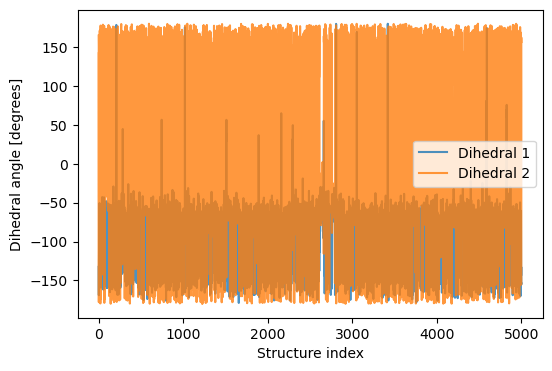

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(dihedrals_deg[:, 0], label='Dihedral 1', alpha=0.8)
plt.plot(dihedrals_deg[:, 1], label='Dihedral 2', alpha=0.8)
plt.xlabel('Structure index')
plt.ylabel('Dihedral angle [degrees]')
plt.legend()
plt.show()


## Ramachandran plot

We can query standard protein backbone angles ($\phi$ and $\psi$) and generate a 2D Ramachandran plot:


In [6]:
phi, psi = msm.structure.get_dihedral_angles(molsys, phi=True, psi=True)
phi_deg = msm.pyunitwizard.convert(phi, to_unit='degrees')
psi_deg = msm.pyunitwizard.convert(psi, to_unit='degrees')


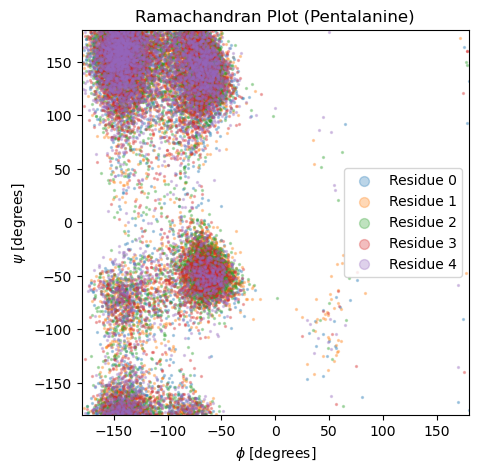

In [7]:
plt.figure(figsize=(5, 5))
for res_idx in range(phi_deg.shape[1]):
    plt.scatter(phi_deg[:, res_idx], psi_deg[:, res_idx], s=2, alpha=0.3, label=f'Residue {res_idx}')
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xlabel('$\phi$ [degrees]')
plt.ylabel('$\psi$ [degrees]')
plt.title('Ramachandran Plot (Pentalanine)')
plt.legend(markerscale=5)
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get dihedral quartets <Tutorial_Get_dihedral_quartets>`: Identify atom quartets for specific dihedral types with {func}`molsysmt.topology.get_dihedral_quartets`.
- {ref}`Set dihedral angles <Tutorial_Set_dihedral_angles>`: Set new values for specific dihedral angles with {func}`molsysmt.structure.set_dihedral_angles`.
- {ref}`Shift dihedral angles <Tutorial_Shift_dihedral_angles>`: Increment or decrement dihedral angle values with {func}`molsysmt.structure.shift_dihedral_angles`.
:::
